In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import abtem
import ase
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve
from skimage.morphology import disk
from scipy.signal.windows import hann
from quantem.core.visualization.custom_normalizations import NormalizationConfig
from matplotlib.patches import Rectangle
from scipy.signal import fftconvolve
from quantem.diffractive_imaging.logger_ptychography import LoggerPtychography
import numpy as np
from scipy.signal import fftconvolve
from scipy.ndimage import maximum_filter, label, find_objects
from scipy.ndimage import shift
from scipy.ndimage import zoom
from skimage.registration import phase_cross_correlation

def crop_white_border(rgba):
    # Convert to grayscale and find non-white rows/cols
    gray = rgba[..., :3].mean(axis=2)
    mask = gray < 255
    rows = np.any(mask, axis=1)
    cols = np.any(mask, axis=0)
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]
    return rgba[rmin:rmax+1, cmin:cmax+1]
from scipy.ndimage import shift as nd_shift

from pathlib import Path

import numpy as np
import torch

import quantem as em
from quantem.core import config
from quantem.core.datastructures import Dataset4dstem
from quantem.core.ml import CNN2d
from quantem.core.visualization import show_2d

from importlib.metadata import version # Temporary fix for version check
print(f"quantEM version: {version("quantem")}")

# from quantem.core.utils.imaging_utils import detect_bragg_disks, bragg_disks_to_masks

from quantem.diffractive_imaging import (
    PtychographyDatasetRaster,
    DetectorPixelated,
    ObjectDIP,
    ObjectPixelated,
    ProbeDIP,
    ProbePixelated,
    Ptychography,
)

import abtem
import ase
import logging
logging.getLogger("hyperspy").setLevel(logging.ERROR)
def cmplx_array_to_rgba(cmplx_valued_array, vmin=0.02, vmax=0.98):
    scaled_amplitude = np.abs(cmplx_valued_array)
    vmin, vmax = np.quantile(scaled_amplitude, [vmin, vmax])
    scaled_amplitude = np.clip(scaled_amplitude, vmin, vmax)
    scaled_amplitude = (scaled_amplitude - vmin) / (vmax - vmin)
    scaled_phase = np.angle(cmplx_valued_array)
    rgba = em.visualization.visualization_utils.array_to_rgba(scaled_amplitude, scaled_phase)
    return rgba

def real_array_to_rgba(real_valued_array, vmin=0.02, vmax=0.98, cmap='gray'):
    scaled_amplitude = np.abs(real_valued_array)
    vmin, vmax = np.quantile(scaled_amplitude, [vmin, vmax])
    scaled_amplitude = np.clip(scaled_amplitude, vmin, vmax)
    scaled_amplitude = (scaled_amplitude - vmin) / (vmax - vmin)
    scaled_phase = None
    rgba = em.visualization.visualization_utils.array_to_rgba(scaled_amplitude, scaled_phase, cmap=cmap)
    return rgba

from abtem.core.energy import energy2sigma

def subpixel_shift(img, shift):
    """
    Circularly shift a 2D (or 3D with leading singleton) array by a
    sub-pixel amount using the Fourier shift theorem.
    shift: (dy, dx) in pixels, applied along the last two axes.
    Positive dx shifts content to the right (same convention as np.roll).
    """
    dy, dx = shift
    *_, ny, nx = img.shape
    
    F = np.fft.fft2(img, axes=(-2, -1))
    
    ky = np.fft.fftfreq(ny)[:, None]
    kx = np.fft.fftfreq(nx)[None, :]
    
    phase_ramp = np.exp(-2j * np.pi * (ky * dy + kx * dx))
    
    F_shifted = F * phase_ramp
    shifted = np.fft.ifft2(F_shifted, axes=(-2, -1))
    
    # if the input was real, the output should be too (up to numerical noise)
    if np.isrealobj(img):
        shifted = shifted.real
    
    return shifted

def normalize(img):
    img = img.astype(np.float64)
    img -= img.mean()
    norm = np.linalg.norm(img)
    return img / norm if norm > 0 else img

def parabolic_subpixel_peak(corr, r, c):
    def subpixel_1d(f_minus, f_0, f_plus):
        denom = (f_minus - 2*f_0 + f_plus)
        if denom == 0:
            return 0.0
        return 0.5 * (f_minus - f_plus) / denom
    dr = subpixel_1d(corr[r-1, c], corr[r, c], corr[r+1, c])
    dc = subpixel_1d(corr[r, c-1], corr[r, c], corr[r, c+1])
    return r + dr, c + dc

def compute_global_shift_xcorr(img_ref, img_target, upsample_factor=20):
    """
    Compute the global (row_shift, col_shift) i.e. (dy, dx) that best
    aligns img_target to img_ref, using Fourier-based phase cross-correlation.

    Parameters
    ----------
    img_ref : reference image (e.g. gt_image)
    img_target : image to register against the reference (e.g. phase)
    upsample_factor : controls sub-pixel precision (20 -> 1/20 px precision)

    Returns
    -------
    shift : (dy, dx) — apply as target_shifted = shift(img_target, shift) to align it to img_ref
    error : normalized RMS registration error
    diffphase : global phase difference (usually irrelevant here)
    """
    shift, error, diffphase = phase_cross_correlation(
        img_ref, img_target, upsample_factor=upsample_factor, normalization='phase'
    )
    return shift, error, diffphase

quantEM version: 0.1.9


In [4]:
def generate_potential(atoms, semiangle_cutoff, gpts=64, dose=1e15, pixels_in_diff_pattern=256):
    pot_gpts = pixels_in_diff_pattern *2
    # pot_gpts = 16384
    lc = 4
    layer_thickness = lc * np.sqrt(3)/3
    potential = abtem.Potential(
        atoms,
        gpts=(pot_gpts, pot_gpts),
        slice_thickness= layer_thickness,
        device='cpu',
        projection='infinite'
    ).build(
        lazy=False
    )


    energy = 300e3
    # semiangle_cutoff = [8,12,16]
    # semiangle_cutoff = 12

    aberrations = {
        "C10":100,
        "C12":200,
        "C21":30000,
        "C30": 10000
    }
    aberrations = {
        "C10":0,#100,
        "C12":0,#200,
        "C21":0,#30000,
        "C30": 0#10000
    }

    probe = abtem.Probe(
        energy=energy,
        semiangle_cutoff=semiangle_cutoff,
        aberrations=aberrations,
        device='cpu',
    ).match_grid(
        potential
    )
    start = [0,0]
    end = [potential.extent[0],potential.extent[1]]
    gpts = gpts

    grid_scan = abtem.GridScan(
        start=start,
        end=end,
        gpts=(gpts+1, gpts+1),
        endpoint=True
    )

    detector = abtem.PixelatedDetector(
        max_angle=None
    )

    # fig,ax = plt.subplots()
    # abtem.show_atoms(atoms,ax=ax)
    # grid_scan.add_to_plot(ax)
    measurement = probe.scan(
        potential,
        grid_scan,
        detector,
    ).compute()


    measurement_cropped = measurement.crop(gpts=(pixels_in_diff_pattern,pixels_in_diff_pattern))


    intensity_measurement_noisy = measurement_cropped.poisson_noise(dose, seed=42)
    dataset_noisy = intensity_measurement_noisy.to_quantem()
    dset_6 = dataset_noisy

    return potential, dset_6

In [5]:
def preprocess_set(dset_6, semiangle_cutoff, force_com_rotation=0, rng=0, num_iters=125, batch_size=128, device="cuda:1"):
    pdset_6 = PtychographyDatasetRaster.from_dataset4dstem(dset_6)#, wave_ground_truth=dset_wave_ground_truth)
    aberrations = {
        "C10":0,#100,
        "C12":0,#200,
        "C21":0,#30000,
        "C30": 0#10000
    }
    PROBE_ENERGY = 300e3
    probe_params = {
        "energy": PROBE_ENERGY,
        "C10": aberrations["C10"],
        "semiangle_cutoff": semiangle_cutoff,
        "C21": aberrations["C21"],
        "C12": aberrations["C12"],
        "C30": aberrations["C30"]
    }

    pdset_6.preprocess(
        force_com_rotation=force_com_rotation,
        force_com_transpose=0,
        plot_com=False,
        probe_energy=PROBE_ENERGY,
        com_fit_function='no_shift'
    )

    obj_model_pix = ObjectPixelated.from_uniform( # also from_array and from_random 
        obj_type="complex",
        num_slices=1,
    )

    probe_model_pix = ProbePixelated.from_params(
        probe_params=probe_params,
    )

    detector_model = DetectorPixelated()


    # logger = None
    logger_pix = LoggerPtychography(
        log_dir = "./logs",
        run_prefix=dset_6.name,
        run_suffix="pix",
        log_images_every=10,
        log_probe_images=False,
    )

    ptycho_pix_6 = Ptychography.from_models( 
        dset=pdset_6,
        obj_model=obj_model_pix,
        probe_model=probe_model_pix,
        detector_model=detector_model,
        logger=logger_pix,
        rng=rng,
        #wave_ground_truth=dset_wave_ground_truth,
    )

    ptycho_pix_6.preprocess(
        obj_padding_px=(0, 0),
        val_ratio=0.0,
    )
    return ptycho_pix_6, pdset_6

def reconstruct_object(ptycho_pix_6, semiangle_cutoff, force_com_rotation=0, rng=0, num_iters=125, batch_size=128, device="cuda:1", reset=True):




    scheduler_params = {
        "object": { ## scheduler kwargs are passed to the scheduler (of type type)
            "type": "plateau", ## i like plateau for many cases
            "factor":0.2,

        },
        "probe": {
            "type": "plateau",
            "factor":0.2,

        },
        "dataset": { 
            "type": "plateau",  ## exp is also frequently used 
            "factor":0.2,
        }
    }

    constraints_stage1 = {
        "object": {'identical_slices': True,
        },
    }
    
    opt_params = {
            "object": {
                "type": "adamw", 
                "lr": 1e-3, 
            },
            "probe": {
                "type": "adamw", 
                "lr": 1e-5, 
            },
            "dataset": { ### for optimizing over descan shifts and probe positions
                "type": "adamw",
                "lr": 0.0,
            }
    }
    ptycho_pix_reconstruct_6 = ptycho_pix_6.reconstruct(
        num_iters=num_iters,
        reset=reset,
        optimizer_params=opt_params,
        scheduler_params=scheduler_params,
        constraints=constraints_stage1, 
        batch_size=batch_size,
        device=device,
        store_snapshots_every=1,
        autograd=False,
    )
    return ptycho_pix_reconstruct_6

def preprocess_set_multislice(dset_6, semiangle_cutoff, slices=3, thickness=10, force_com_rotation=0, rng=0, num_iters=125, batch_size=128, device="cuda:1"):
    pdset_6 = PtychographyDatasetRaster.from_dataset4dstem(dset_6)#, wave_ground_truth=dset_wave_ground_truth)
    aberrations = {
        "C10":0,#100,
        "C12":0,#200,
        "C21":0,#30000,
        "C30": 0#10000
    }
    PROBE_ENERGY = 300e3
    probe_params = {
        "energy": PROBE_ENERGY,
        "C10": aberrations["C10"],
        "semiangle_cutoff": semiangle_cutoff,
        "C21": aberrations["C21"],
        "C12": aberrations["C12"],
        "C30": aberrations["C30"]
    }

    pdset_6.preprocess(
        force_com_rotation=force_com_rotation,
        force_com_transpose=0,
        plot_com=False,
        probe_energy=PROBE_ENERGY,
        com_fit_function='no_shift'
    )

    obj_model_pix = ObjectPixelated.from_uniform( # also from_array and from_random 
        obj_type="complex",
        num_slices=slices,
        slice_thicknesses=thickness,
    )

    probe_model_pix = ProbePixelated.from_params(
        probe_params=probe_params,
    )

    detector_model = DetectorPixelated()


    # logger = None
    logger_pix = LoggerPtychography(
        log_dir = "./logs",
        run_prefix=dset_6.name,
        run_suffix="pix",
        log_images_every=10,
        log_probe_images=False,
    )

    ptycho_pix_6 = Ptychography.from_models( 
        dset=pdset_6,
        obj_model=obj_model_pix,
        probe_model=probe_model_pix,
        detector_model=detector_model,
        logger=logger_pix,
        rng=rng,
        #wave_ground_truth=dset_wave_ground_truth,
    )

    ptycho_pix_6.preprocess(
        obj_padding_px=(0, 0),
        val_ratio=0.0,
    )
    return ptycho_pix_6, pdset_6

def reconstruct_object(ptycho_pix_6, semiangle_cutoff, force_com_rotation=0, rng=0, num_iters=125, batch_size=128, device="cuda:1", reset=True):




    scheduler_params = {
        "object": { ## scheduler kwargs are passed to the scheduler (of type type)
            "type": "plateau", ## i like plateau for many cases
            "factor":0.2,

        },
        "probe": {
            "type": "plateau",
            "factor":0.2,

        },
        "dataset": { 
            "type": "plateau",  ## exp is also frequently used 
            "factor":0.2,
        }
    }

    constraints_stage1 = {
        "object": {
        },
    }
    
    opt_params = {
            "object": {
                "type": "adamw", 
                "lr": 1e-3, 
            },
            "probe": {
                "type": "adamw", 
                "lr": 1e-4, 
            },
            "dataset": { ### for optimizing over descan shifts and probe positions
                "type": "adamw",
                "lr": 0.0,
            }
    }
    ptycho_pix_reconstruct_6 = ptycho_pix_6.reconstruct(
        num_iters=num_iters,
        reset=reset,
        optimizer_params=opt_params,
        scheduler_params=scheduler_params,
        constraints=constraints_stage1, 
        batch_size=batch_size,
        device=device,
        store_snapshots_every=1,
        autograd=False,
    )
    return ptycho_pix_reconstruct_6

In [6]:
import numpy as np
import atomap.api as am
from scipy.signal import fftconvolve
import matplotlib.pyplot as plt
import hyperspy.api as hs
from scipy.ndimage import zoom


/home/wdekleijne/git-repos/willem-playground/.venv/lib/python3.12/site-packages/hyperspy/misc/_utils.py:1590: VisibleDeprecationWarning: Importing `LazyComplexSignal1D` from `hyperspy._signals.complex_signal1d` is deprecated and will be removed in the HyperSpy 3.0 release. Import it from `hyperspy.signals` instead.
  warnings.warn(
/home/wdekleijne/git-repos/willem-playground/.venv/lib/python3.12/site-packages/hyperspy/misc/_utils.py:1590: VisibleDeprecationWarning: Importing `LazySignal1D` from `hyperspy._signals.signal1d` is deprecated and will be removed in the HyperSpy 3.0 release. Import it from `hyperspy.signals` instead.
  warnings.warn(


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.registration import phase_cross_correlation
from scipy.signal import fftconvolve

def find_best_shift_xcorr(reference, moving, upsample_factor=20, normalization=None):
    """
    Find the sub-pixel shift that best aligns `moving` to `reference`
    using FFT-based phase cross-correlation, and compute a normalized
    cross-correlation (NCC) surface around the peak to assess goodness of fit.

    Parameters
    ----------
    reference : 2D array (e.g. normalized potential)
    moving : 2D array (e.g. normalized reconstructed phase), same shape as reference
    upsample_factor : int
        Sub-pixel precision = 1/upsample_factor of a pixel
    normalization : None or "phase"
        Passed to phase_cross_correlation; "phase" can help if there's
        amplitude mismatch between the two images

    Returns
    -------
    shift : (row_shift, col_shift) -- shift to apply to `moving` to align to `reference`
    error : registration error metric from phase_cross_correlation
    ncc_peak : peak value of the normalized cross-correlation (0-1, higher = better match)
    ncc_map : the local NCC surface for plotting
    """
    assert reference.shape == moving.shape, "Images must be the same shape"

    # --- Sub-pixel shift via FFT phase correlation ---
    shift, error, diffphase = phase_cross_correlation(
        reference, moving,
        upsample_factor=upsample_factor,
        normalization=normalization,
    )

    # --- Full-resolution NCC map for visualizing correlation goodness ---
    ref_norm = (reference - reference.mean()) / (reference.std() + 1e-12)
    mov_norm = (moving - moving.mean()) / (moving.std() + 1e-12)

    # cross-correlate via FFT convolution with flipped kernel
    ncc_map = fftconvolve(ref_norm, mov_norm[::-1, ::-1], mode="same")
    ncc_map /= ref_norm.size  # normalize by number of pixels -> range ~[-1, 1]

    ncc_peak = ncc_map.max()

    return shift, error, ncc_peak, ncc_map

def plot_xcorr_results(reference, moving, shift, ncc_map, ncc_peak,
                        titles=("Reference", "Moving", "Shifted moving", "NCC surface"),
                        overlay_alpha=0.4):
    from scipy.ndimage import shift as ndi_shift

    shifted_moving = ndi_shift(moving, shift=shift, order=3, mode="constant", cval=0)

    # build a red overlay mask from the reference (normalized 0-1 for alpha scaling)
    ref_norm01 = (reference - reference.min()) / (reference.max() - reference.min() + 1e-12)

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    axes[0].imshow(reference, cmap="gray")
    axes[0].set_title(titles[0])

    # --- Moving with reference overlay ---
    axes[1].imshow(moving, cmap="gray")
    axes[1].imshow(np.ones_like(reference), cmap="Reds", alpha=ref_norm01 * overlay_alpha)
    axes[1].set_title(f"{titles[1]}\n(red = reference)")

    # --- Shifted moving with reference overlay ---
    axes[2].imshow(shifted_moving, cmap="gray")
    axes[2].imshow(np.ones_like(reference), cmap="Reds", alpha=ref_norm01 * overlay_alpha)
    axes[2].set_title(f"{titles[2]}\nshift=({shift[0]:.3f}, {shift[1]:.3f}) px\n(red = reference)")

    # zoom into a window around the correlation peak for readability
    cy, cx = np.array(ncc_map.shape) // 2
    win = min(60, cy, cx)
    ncc_crop = ncc_map[cy-win:cy+win, cx-win:cx+win]

    im = axes[3].imshow(ncc_crop, cmap="viridis")
    peak_local = np.unravel_index(np.argmax(ncc_crop), ncc_crop.shape)
    axes[3].plot(peak_local[1], peak_local[0], "r+", markersize=15, markeredgewidth=2)
    axes[3].set_title(f"{titles[3]}\npeak NCC = {ncc_peak:.4f}")
    fig.colorbar(im, ax=axes[3], label="NCC")

    for ax in axes[:3]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()




In [8]:
def count_atoms(image, threshold=0.5, accurate=False, vis=False):
    gt_image = image.astype(np.float64)
    gt_image -= gt_image.min()  # atomap doesn't like negative values

    gt_signal = hs.signals.Signal2D(gt_image)

    # separation: ~half the nearest-neighbor atom distance, in pixels.
    # Tune this based on your lattice spacing in the 256x256 sampling.
    separation = 1

    atom_positions = am.get_atom_positions(gt_signal, separation=separation, pca=True, threshold_rel=threshold)

    sublattice = am.Sublattice(atom_positions, image=gt_image, color='red')
    sublattice.find_nearest_neighbors()
    sublattice.refine_atom_positions_using_center_of_mass(show_progressbar=False)
    if accurate:
        sublattice.refine_atom_positions_using_2d_gaussian(show_progressbar=False)
    if vis:
        sublattice.plot()  # sanity check the fitted positions over the ground truth
        plt.show()

    refined_positions = np.array(
        [[atom.pixel_x, atom.pixel_y] for atom in sublattice.atom_list]
    )
    return refined_positions

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, shift as ndi_shift
from scipy.signal import fftconvolve
from skimage.registration import phase_cross_correlation


def rasterize_points(points, image_shape, sigma=2.0):
    """
    Turn a point list (x, y) into a smooth density image via Gaussian-blurred
    delta functions. Sub-pixel point positions are distributed with bilinear
    weights before blurring so we don't lose precision to rounding.
    """
    img = np.zeros(image_shape, dtype=np.float64)
    xs, ys = points[:, 0], points[:, 1]

    x0 = np.floor(xs).astype(int)
    y0 = np.floor(ys).astype(int)
    fx = xs - x0
    fy = ys - y0

    for dx, dy, wx, wy in [(0, 0, 1 - fx, 1 - fy),
                            (1, 0, fx, 1 - fy),
                            (0, 1, 1 - fx, fy),
                            (1, 1, fx, fy)]:
        xi = x0 + dx
        yi = y0 + dy
        valid = (xi >= 0) & (xi < image_shape[1]) & (yi >= 0) & (yi < image_shape[0])
        np.add.at(img, (yi[valid], xi[valid]), (wx * wy)[valid])

    return gaussian_filter(img, sigma=sigma)


from skimage.feature import peak_local_max

from skimage.feature import peak_local_max

def parabolic_subpixel_peak(map_2d, peak_rc):
    """Refine an integer (row, col) peak location to sub-pixel accuracy
    via a 1D parabolic fit along each axis independently."""
    r, c = peak_rc
    r, c = int(r), int(c)
    if 0 < r < map_2d.shape[0] - 1 and 0 < c < map_2d.shape[1] - 1:
        denom_r = map_2d[r-1, c] - 2*map_2d[r, c] + map_2d[r+1, c]
        denom_c = map_2d[r, c-1] - 2*map_2d[r, c] + map_2d[r, c+1]
        dr = 0.5 * (map_2d[r-1, c] - map_2d[r+1, c]) / denom_r if denom_r != 0 else 0.0
        dc = 0.5 * (map_2d[r, c-1] - map_2d[r, c+1]) / denom_c if denom_c != 0 else 0.0
        return r + dr, c + dc
    return float(r), float(c)


def cross_correlate_point_clouds(points_ref, points_mov, image_shape,
                                  sigma=2.0, upsample_factor=50):
    """
    Cross-correlate two point clouds by rasterizing them into density images
    and finding the sub-pixel shift that maximizes their correlation.
    Does NOT require equal point counts or 1:1 correspondence.

    Returns
    -------
    shift : (dx, dy) shift to apply to points_mov to align with points_ref
            (from FFT phase correlation, sub-pixel accurate)
    error : phase_cross_correlation registration error (lower = better)
    ncc_peak : global peak of the normalized cross-correlation (0-1, higher = better match)
    shift_centered : (dx, dy) sub-pixel shift at the NCC local peak closest to zero-shift,
                      refined via parabolic interpolation; useful as a sanity check
                      against `shift` when the global NCC max is a spurious/periodic peak
    img_ref, img_mov : the rasterized density images (for inspection/plotting)
    ncc_map : the full NCC map
    """
    img_ref = rasterize_points(points_ref, image_shape, sigma=sigma)
    img_mov = rasterize_points(points_mov, image_shape, sigma=sigma)

    shift_rc, error, _ = phase_cross_correlation(img_ref, img_mov, upsample_factor=upsample_factor)
    shift = np.array([shift_rc[1], shift_rc[0]])  # -> (dx, dy)

    ref_norm = (img_ref - img_ref.mean()) / (img_ref.std() + 1e-12)
    mov_norm = (img_mov - img_mov.mean()) / (img_mov.std() + 1e-12)
    ncc_map = fftconvolve(ref_norm, mov_norm[::-1, ::-1], mode="same") / ref_norm.size
    ncc_peak = ncc_map.max()

    # sub-pixel shift (dx, dy) at the NCC peak closest to zero-shift
    center = np.array([ncc_map.shape[0] // 2, ncc_map.shape[1] // 2])
    local_maxima = peak_local_max(ncc_map, min_distance=3)  # (row, col) coords

    if len(local_maxima) > 0:
        dists = np.linalg.norm(local_maxima - center, axis=1)
        nearest_idx = np.argmin(dists)
        peak_rc = local_maxima[nearest_idx]
        r_sub, c_sub = parabolic_subpixel_peak(ncc_map, peak_rc)
        offset_rc = np.array([r_sub, c_sub]) - center   # (drow, dcol) = (dy, dx)
        shift_centered = np.array([offset_rc[1], offset_rc[0]])  # -> (dx, dy)
    else:
        shift_centered = np.array([0.0, 0.0])

    return shift, error, ncc_peak, shift_centered, img_ref, img_mov, ncc_map

def cross_correlate_simple(points_ref, points_mov, image_shape,
                                  sigma=2.0, upsample_factor=50):
    """
    Cross-correlate two point clouds by rasterizing them into density images
    and finding the sub-pixel shift that maximizes their correlation.
    Does NOT require equal point counts or 1:1 correspondence.

    Returns
    -------
    shift : (dx, dy) shift to apply to points_mov to align with points_ref
            (from FFT phase correlation, sub-pixel accurate)
    error : phase_cross_correlation registration error (lower = better)
    ncc_peak : global peak of the normalized cross-correlation (0-1, higher = better match)
    shift_centered : (dx, dy) sub-pixel shift at the NCC local peak closest to zero-shift,
                      refined via parabolic interpolation; useful as a sanity check
                      against `shift` when the global NCC max is a spurious/periodic peak
    img_ref, img_mov : the rasterized density images (for inspection/plotting)
    ncc_map : the full NCC map
    """


    shift_rc, error, _ = phase_cross_correlation(points_ref, points_mov, upsample_factor=upsample_factor)
    shift = np.array([shift_rc[1], shift_rc[0]])  # -> (dx, dy)

    ref_norm = (img_ref - img_ref.mean()) / (img_ref.std() + 1e-12)
    mov_norm = (img_mov - img_mov.mean()) / (img_mov.std() + 1e-12)
    ncc_map = fftconvolve(ref_norm, mov_norm[::-1, ::-1], mode="same") / ref_norm.size
    ncc_peak = ncc_map.max()

    # sub-pixel shift (dx, dy) at the NCC peak closest to zero-shift
    center = np.array([ncc_map.shape[0] // 2, ncc_map.shape[1] // 2])
    local_maxima = peak_local_max(ncc_map, min_distance=3)  # (row, col) coords

    if len(local_maxima) > 0:
        dists = np.linalg.norm(local_maxima - center, axis=1)
        nearest_idx = np.argmin(dists)
        peak_rc = local_maxima[nearest_idx]
        r_sub, c_sub = parabolic_subpixel_peak(ncc_map, peak_rc)
        offset_rc = np.array([r_sub, c_sub]) - center   # (drow, dcol) = (dy, dx)
        shift_centered = np.array([offset_rc[1], offset_rc[0]])  # -> (dx, dy)
    else:
        shift_centered = np.array([0.0, 0.0])

    return shift, error, ncc_peak, shift_centered, img_ref, img_mov, ncc_map

In [10]:
import os
import csv
import numpy as np
import matplotlib.pyplot as plt


def save_shift_result(rngi, shift, ncc_peak, shift_0, error, csv_path):
    """Append one row of (rngi, shift_x, shift_y, ncc_peak, error) to the CSV."""
    with open(csv_path, "a", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([rngi, shift[0], shift[1], ncc_peak, shift_0[0], shift_0[1], error])


def save_object_image(obj, rngi, convergence_angle, results_dir, tag="reconstruction", optimized=False, batch_size=256, num_iters=125, gpts=64):
    """Save np.angle(obj) as a PNG, named with rngi and convergence angle."""
    fname = os.path.join(results_dir, f"{tag}_conv{convergence_angle}_rng{rngi}_batchsize{batch_size}_iters{num_iters}_gpts{gpts}_optimized{optimized}.png")
    fig, ax = plt.subplots(figsize=(8, 8))
    im = ax.imshow(np.angle(obj), cmap="gray")
    ax.set_title(f"Reconstructed phase | conv={convergence_angle}, rng={rngi}")
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.savefig(fname, dpi=150)
    plt.close(fig)
    return fname


def plot_point_cloud_xcorr(img_ref, img_mov, shift, ncc_map, ncc_peak,
                            overlay_alpha=0.5, save_path=None):
    mov_shifted = ndi_shift(img_mov, shift=(shift[1], shift[0]), order=3, mode="constant", cval=0)

    ref_norm01 = (img_ref - img_ref.min()) / (img_ref.max() - img_ref.min() + 1e-12)

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    axes[0].imshow(img_ref, cmap="gray")
    axes[0].set_title("Reference density")

    axes[1].imshow(img_mov, cmap="gray")
    axes[1].imshow(np.ones_like(img_ref), cmap="Reds", alpha=ref_norm01 * overlay_alpha)
    axes[1].set_title("Moving density\n(red = reference)")

    axes[2].imshow(mov_shifted, cmap="gray")
    axes[2].imshow(np.ones_like(img_ref), cmap="Reds", alpha=ref_norm01 * overlay_alpha)
    axes[2].set_title(f"Shifted moving\nshift=({shift[0]:.3f}, {shift[1]:.3f}) px\n(red = reference)")

    cy, cx = np.array(ncc_map.shape) // 2
    win = min(60, cy, cx)
    ncc_crop = ncc_map[cy-win:cy+win, cx-win:cx+win]
    im = axes[3].imshow(ncc_crop, cmap="viridis")
    peak_local = np.unravel_index(np.argmax(ncc_crop), ncc_crop.shape)
    axes[3].plot(peak_local[1], peak_local[0], "r+", markersize=15, markeredgewidth=2)
    axes[3].set_title(f"NCC surface\npeak = {ncc_peak:.4f}")
    fig.colorbar(im, ax=axes[3], label="NCC")

    for ax in axes[:3]:
        ax.axis("off")

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=150)

    plt.close(fig)

In [11]:
def find_optimal_shift(ptycho_pix_reconstruct_1, pdset_6, semiangle_cutoff, device="cuda:1", rng=0):
    initial_guess = ptycho_pix_reconstruct_1.obj
    shift_results = []
    for shift_x in np.linspace(-2, 2, 5):
        for shift_y in np.linspace(-2, 2, 5):
            shifted_obj = subpixel_shift(initial_guess, shift=(shift_y, shift_x))
            obj_model_pix = ObjectPixelated.from_array(
                initial_obj=shifted_obj,
                obj_type="complex",
            )
            detector_model = DetectorPixelated()

            aberrations = {
                "C10":0,#100,
                "C12":0,#200,
                "C21":0,#30000,
                "C30": 0#10000
            }
            PROBE_ENERGY = 300e3
            probe_params = {
                "energy": PROBE_ENERGY,
                "C10": aberrations["C10"],
                "semiangle_cutoff": semiangle_cutoff,
                "C21": aberrations["C21"],
                "C12": aberrations["C12"],
                "C30": aberrations["C30"]
            }
            probe_model_pix = ProbePixelated.from_params(
                probe_params=probe_params,
            )
            
            ptycho_pix_6 = Ptychography.from_models( 
                dset=pdset_6,
                obj_model=obj_model_pix,
                probe_model=probe_model_pix,
                detector_model=detector_model,
                rng=rng,
            )
            ptycho_pix_6.preprocess(
                obj_padding_px=(0, 0),
                val_ratio=0.0,
            )
            opt_params = {
            "object": {
                "type": "adamw", 
                "lr": 1e-2, 
            },
            "probe": {
                "type": "adamw", 
                "lr": 1e-3, 
            },
            "dataset": { ### for optimizing over descan shifts and probe positions
                "type": "adamw",
                "lr": 0.0,
            }
            }
            scheduler_params = {
                "object": { ## scheduler kwargs are passed to the scheduler (of type type)
                    "type": "plateau", ## i like plateau for many cases
                    "factor":0.2,

                },
                "probe": {
                    "type": "plateau",
                    "factor":0.2,

                },
                "dataset": { 
                    "type": "plateau",  ## exp is also frequently used 
                    "factor":0.2,
                }
            }

            constraints_stage1 = {
                "object": {
                },
            }
            ptycho_pix_reconstruct_2 = ptycho_pix_6.reconstruct(
                num_iters=10,
                reset=True,
                optimizer_params=opt_params,
                scheduler_params=scheduler_params,
                constraints=constraints_stage1, 
                batch_size=256,
                device=device,
                store_snapshots_every=1,
                autograd=False,
            )
            total_loss = ptycho_pix_reconstruct_2._iter_losses[-1]
            # save shift_x, shift_y, and total_loss to a list or file for later analysis
            shift_results.append((shift_x, shift_y, total_loss))
            print(f"Shift (x={shift_x}, y={shift_y}) -> Total Loss: {total_loss}")
                
    # Unpack results
    shift_results_arr = np.array(shift_results)  # columns: shift_x, shift_y, loss
    shift_x_vals = np.unique(shift_results_arr[:, 0])
    shift_y_vals = np.unique(shift_results_arr[:, 1])

    # Reshape losses into a 2D grid (rows = shift_y, cols = shift_x, matching your loop order)
    loss_grid = shift_results_arr[:, 2].reshape(len(shift_x_vals), len(shift_y_vals)).T
    # .T because your loop is: outer=shift_x, inner=shift_y -> array fills row-major as (x, y)
    # after reshape(len(x), len(y)) each row corresponds to one shift_x, so transpose to get (y, x) for imshow/contour

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # --- Heatmap ---
    im = axes[0].imshow(
        loss_grid,
        extent=[shift_x_vals.min(), shift_x_vals.max(), shift_y_vals.min(), shift_y_vals.max()],
        origin="lower",
        aspect="auto",
        cmap="viridis",
    )
    axes[0].set_xlabel("Shift X (px)")
    axes[0].set_ylabel("Shift Y (px)")
    axes[0].set_title("Loss landscape")
    fig.colorbar(im, ax=axes[0], label="Loss")

    # Mark the minimum
    min_idx = np.argmin(shift_results_arr[:, 2])
    best_x, best_y, best_loss = shift_results_arr[min_idx]
    axes[0].plot(best_x, best_y, "r*", markersize=15, label=f"min @ ({best_x:.1f}, {best_y:.1f})")
    axes[0].legend()

    # --- Contour plot ---
    X, Y = np.meshgrid(shift_x_vals, shift_y_vals)
    cs = axes[1].contourf(X, Y, loss_grid, levels=20, cmap="viridis")
    axes[1].contour(X, Y, loss_grid, levels=10, colors="white", linewidths=0.5, alpha=0.5)
    axes[1].plot(best_x, best_y, "r*", markersize=15)
    axes[1].set_xlabel("Shift X (px)")
    axes[1].set_ylabel("Shift Y (px)")
    axes[1].set_title("Loss landscape (contour)")
    fig.colorbar(cs, ax=axes[1], label="Loss")
    # best_x, best_y, pred_loss, spline = find_subpixel_minimum_spline(shift_results)
    # print(f"Sub-pixel minimum: shift_x={best_x:.3f}, shift_y={best_y:.3f}, predicted loss={pred_loss:.4f}")

    # overlay on your contour axes
    axes[1].plot(best_x, best_y, "w+", markersize=15, markeredgewidth=2, label="spline min")
    plt.tight_layout()
    plt.savefig("loss_landscape.png", dpi=150)
    plt.show()

    print(f"Minimum loss {best_loss:.6g} at shift_x={best_x}, shift_y={best_y}")
    return best_x, best_y

In [12]:
from ase.io import write, read

def generate_faceted_particles(vis=True,on_aC=False):
    if on_aC:
        atoms = read('AuNPs_amorphous_carbon.xyz')
    else:
        atoms = read('AuNPs.xyz')

    if vis:
        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 5))
        abtem.show_atoms(
            atoms, ax=ax1,
            title="Two fcc100 slabs, beam view",
            merge=0.1, scale=1,
        )
        abtem.show_atoms(
            atoms, ax=ax2, plane="xz", scale=1,
            title="Side view (xz)", merge=0.1,
        )
        abtem.show_atoms(
            atoms, ax=ax3, plane="yz", scale=1,
            title="Side view (yz)", merge=0.1,
        )
        fig.tight_layout()

    return atoms

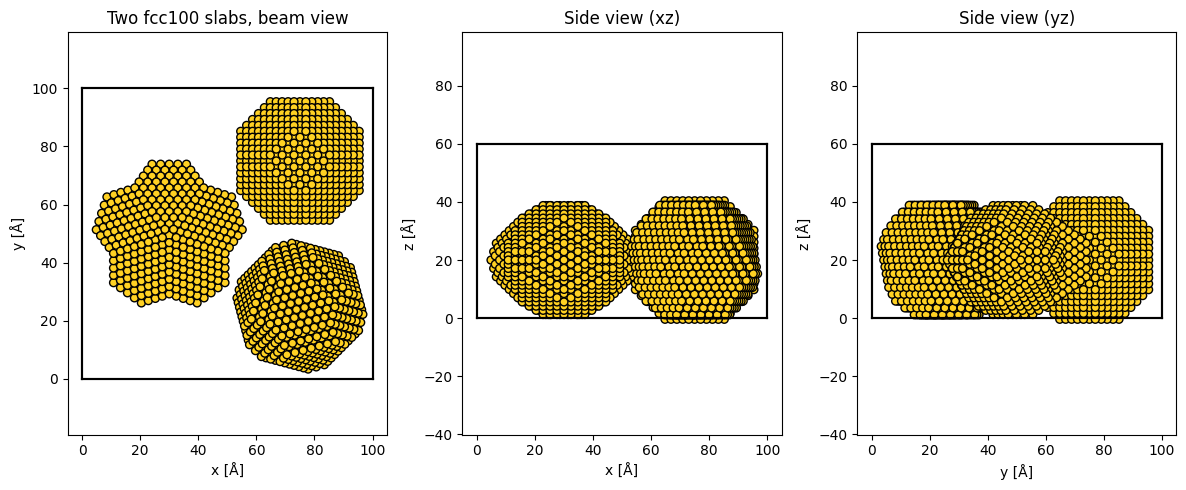

tasks:   0%|          | 0/92 [00:00<?, ?it/s]

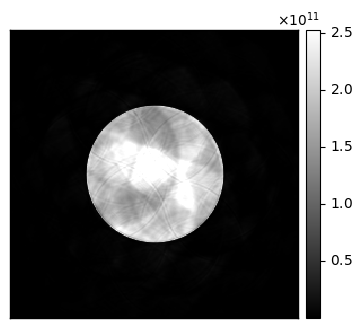

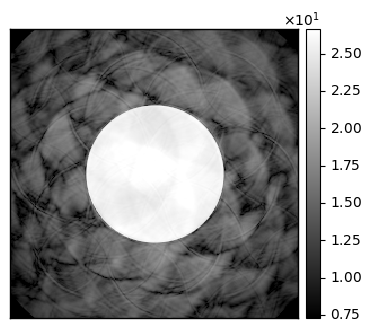

Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to 0.


Normalizing intensities:   0%|          | 0/4225 [00:00<?, ?probe position/s]

Missing probe parameter 'defocus' in probe_params
rngi: 0


  0%|          | 0/125 [00:00<?, ?it/s]

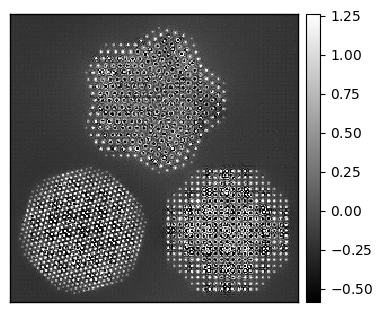

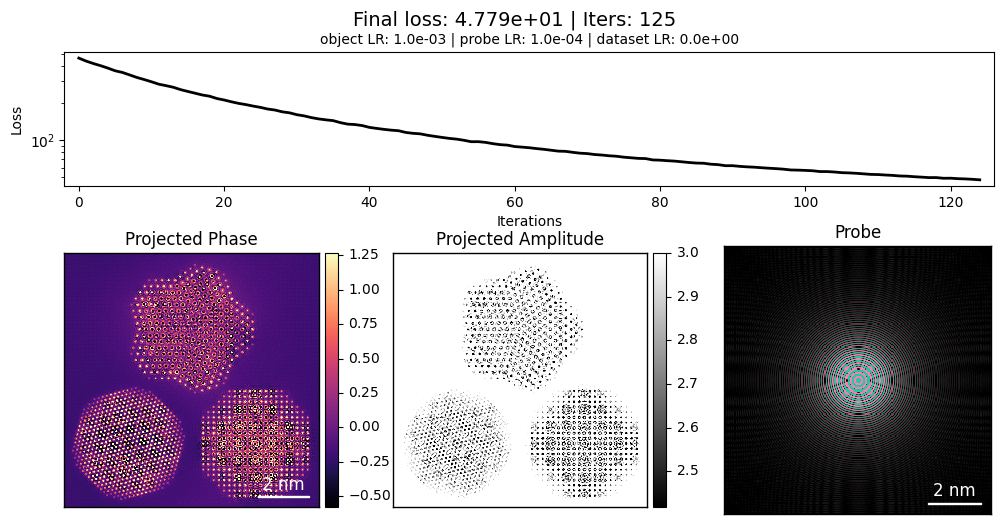

/home/wdekleijne/git-repos/willem-playground/.venv/lib/python3.12/site-packages/atomap/atom_finding_refining.py:604: RuntimeWarning: invalid value encountered in divide
  arr = arr / np.sum(arr, axis=(-1, -2))


Number of atoms in the reconstructed phase upper: 2922  and in the ground truth upper: 1214
Best shift (dx, dy): (10.0600, 4.9400) px
Best shift_0 (dx, dy): (-0.1914, -0.3269) px


/tmp/ipykernel_1847586/1183763399.py:17: RuntimeWarning: invalid value encountered in cast
  x0 = np.floor(xs).astype(int)
/tmp/ipykernel_1847586/1183763399.py:18: RuntimeWarning: invalid value encountered in cast
  y0 = np.floor(ys).astype(int)


KeyboardInterrupt: 

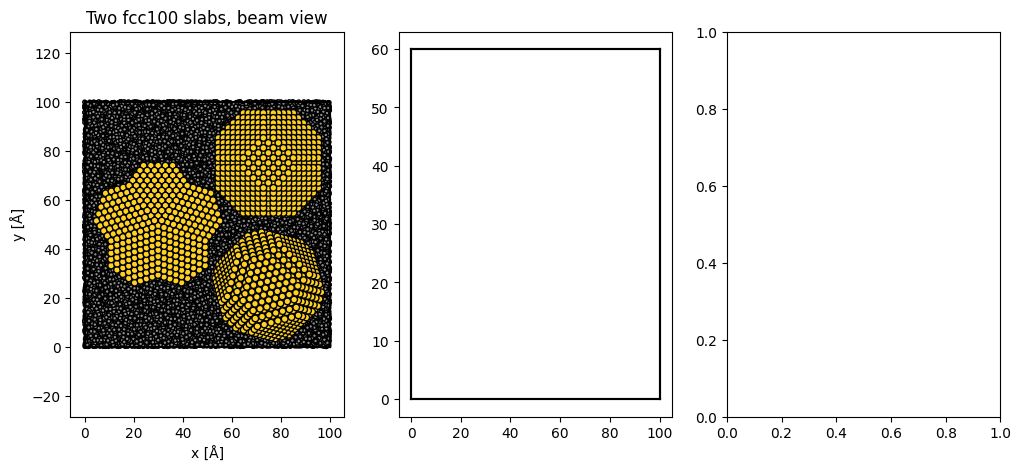

In [13]:
for dosei in [1e15, 1e6]:
    for on_ac in [False, True]:
        for conv_angle in [12]:
            on_aC = on_ac
            convergence_angle = conv_angle
            gpts = 64
            force_com_rotation = 0
            batch_size = 256
            device = "cuda:1"
            num_iters = 125
            reset = True
            d = 10
            dose = dosei
            pixels_in_diff_pattern = 256
            thresh_hex = 0.4
            thresh_hex_gt = 0.2
            slices = 3
            thickness = 15
            # --- setup: one results folder per convergence angle ---
            results_dir = f"results_conv{convergence_angle}_d{d}_gpts{gpts}_dose{dose:.1e}_batchsize{batch_size}_iters{num_iters}_pixels{pixels_in_diff_pattern}_on_aC{on_aC}_300e3"

            os.makedirs(results_dir, exist_ok=True)

            shift_csv_path_first = os.path.join(results_dir, f"shifts_conv{convergence_angle}_batchsize{batch_size}_iters{num_iters}_gpts{gpts}_first.csv")
            shift_csv_path_second = os.path.join(results_dir, f"shifts_conv{convergence_angle}_batchsize{batch_size}_iters{num_iters}_gpts{gpts}_second.csv")
            shift_csv_path_always = os.path.join(results_dir, f"shifts_conv{convergence_angle}_batchsize{batch_size}_iters{num_iters}_gpts{gpts}_always.csv")

            # write header once (only if file doesn't already exist, so re-running doesn't clobber past runs)
            if not os.path.exists(shift_csv_path_first):
                with open(shift_csv_path_first, "w", newline="") as f:
                    writer = csv.writer(f)
                    writer.writerow(["rngi", "shift_x", "shift_y", "ncc_peak", "shift_x_0", 'shift_y_0', "registration_error"])

            if not os.path.exists(shift_csv_path_second):
                with open(shift_csv_path_second, "w", newline="") as f:
                    writer = csv.writer(f)
                    writer.writerow(["rngi", "shift_x", "shift_y", "ncc_peak", "shift_x_0", 'shift_y_0', "registration_error"])

            if not os.path.exists(shift_csv_path_always):
                with open(shift_csv_path_always, "w", newline="") as f:
                    writer = csv.writer(f)
                    writer.writerow(["rngi", "shift_x", "shift_y", "ncc_peak", "shift_x_0", 'shift_y_0', "registration_error"])

            rng = range(0, 1)
            atoms = generate_faceted_particles(vis=True, on_aC=on_aC)
            plt.show()
            potential, noisy_dataset = generate_potential(atoms, convergence_angle, gpts=gpts, dose=dose, pixels_in_diff_pattern=pixels_in_diff_pattern)

            show_2d(noisy_dataset.array[32,32],cbar=True)
            plt.show()
            # noisy_dataset.array = np.where(noisy_dataset.array>=4, noisy_dataset.array,0)
            show_2d(noisy_dataset.array[32,32]**0.125,cbar=True)
            plt.show()
            ptycho_pix_1, pdset_1 = preprocess_set_multislice(noisy_dataset, convergence_angle, slices=slices, thickness=thickness, force_com_rotation=force_com_rotation)


            for rngi in rng:
                print(f'rngi: {rngi}')
                ptycho_pix_reconstruct_1 = reconstruct_object(ptycho_pix_1, convergence_angle, rng=rngi, batch_size=batch_size, device=device, num_iters=num_iters, reset=True)
                show_2d(np.angle(ptycho_pix_reconstruct_1.obj).sum(0),cbar=True)
                plt.show()
                ptycho_pix_reconstruct_1.visualize()
                potential_all = zoom(potential.array[0::1].sum(0), 0.5, order=4)


                recon = np.angle(ptycho_pix_reconstruct_1.obj).sum(0)
                positions_obj = recon.clip(np.percentile(recon,2), np.percentile(recon,99))

                refined_positions_obj = count_atoms(positions_obj, threshold=thresh_hex, vis=False)
                refined_positions_gt= count_atoms(potential_all, threshold=thresh_hex_gt)

                print(f"Number of atoms in the reconstructed phase upper: {len(refined_positions_obj)}  and in the ground truth upper: {len(refined_positions_gt)}")

                obj = ptycho_pix_reconstruct_1.obj[0]

                save_object_image(obj, rngi, convergence_angle, results_dir, optimized=False, batch_size=batch_size, num_iters=num_iters, gpts=gpts)

                image_shape = positions_obj.shape  # e.g. (256, 256)

                shift, error, ncc_peak, shift_0, img_ref, img_mov, ncc_map = cross_correlate_point_clouds(
                    refined_positions_gt, refined_positions_obj, image_shape, sigma=1.0
                )
                print(f"Best shift (dx, dy): ({shift[0]:.4f}, {shift[1]:.4f}) px")
                print(f"Best shift_0 (dx, dy): ({shift_0[0]:.4f}, {shift_0[1]:.4f}) px")

                save_shift_result(rngi, shift, ncc_peak, shift_0, error, shift_csv_path_always)

                xcorr_plot_path = os.path.join(results_dir, f"xcorr_conv{convergence_angle}_rng{rngi}_batchsize{batch_size}_iters{num_iters}_gpts{gpts}_upper.png")
                plot_point_cloud_xcorr(img_ref, img_mov, shift, ncc_map, ncc_peak, save_path=xcorr_plot_path)



[(np.float32(-1.1186621), np.float32(1.5541282)), (np.float32(-0.8764388), np.float32(1.4486997)), (np.float32(-0.83371264), np.float32(1.3350949))]


(<Figure size 1200x400 with 6 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >], dtype=object))

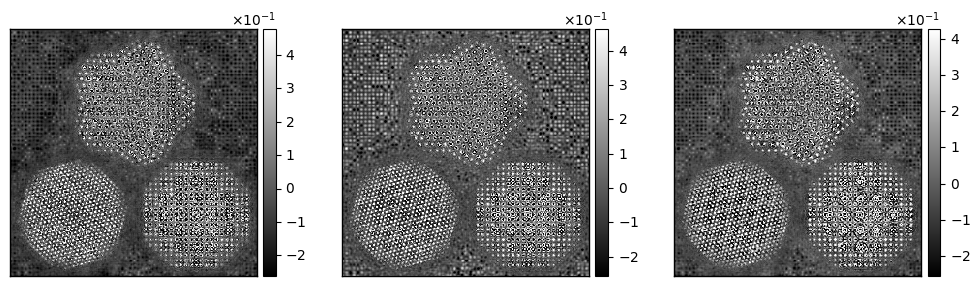

In [14]:
print([(np.angle(ptycho_pix_reconstruct_1.obj[i]).min(),
  np.angle(ptycho_pix_reconstruct_1.obj[i]).max())
 for i in range(ptycho_pix_reconstruct_1.obj.shape[0])])
show_2d([np.angle(ptycho_pix_reconstruct_1.obj[i]) for i in range(ptycho_pix_reconstruct_1.obj.shape[0])],cbar=True)

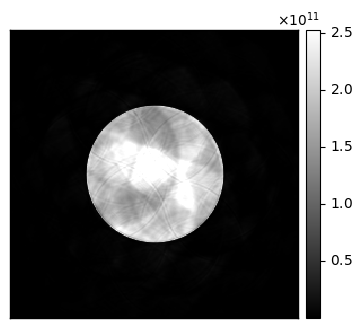

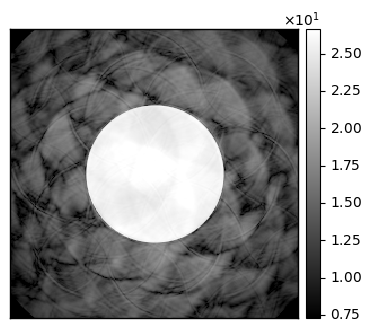

rngi: 0


  0%|          | 0/125 [00:00<?, ?it/s]

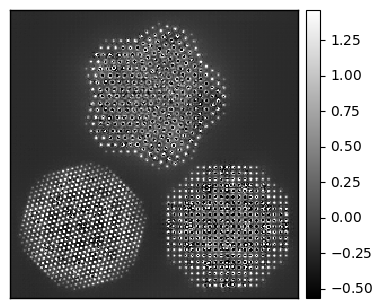

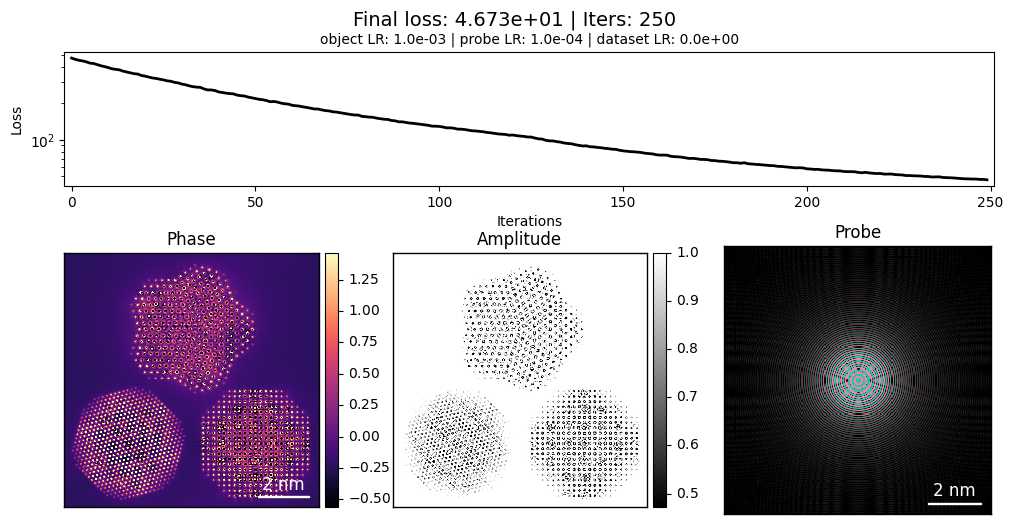

/home/wdekleijne/git-repos/willem-playground/.venv/lib/python3.12/site-packages/atomap/atom_finding_refining.py:604: RuntimeWarning: invalid value encountered in divide
  arr = arr / np.sum(arr, axis=(-1, -2))


Number of atoms in the reconstructed phase upper: 2515  and in the ground truth upper: 1214
Best shift (dx, dy): (0.2800, -0.0400) px
Best shift_0 (dx, dy): (-0.1986, -0.2675) px


/tmp/ipykernel_1847586/1183763399.py:17: RuntimeWarning: invalid value encountered in cast
  x0 = np.floor(xs).astype(int)
/tmp/ipykernel_1847586/1183763399.py:18: RuntimeWarning: invalid value encountered in cast
  y0 = np.floor(ys).astype(int)


In [17]:
for dosei in [1e15]:
    for on_ac in [False]:
        for conv_angle in [12]:
            on_aC = on_ac
            convergence_angle = conv_angle
            gpts = 64
            force_com_rotation = 0
            batch_size = 256
            device = "cuda:1"
            num_iters = 125
            reset = True
            d = 10
            dose = dosei
            pixels_in_diff_pattern = 256
            thresh_hex = 0.4
            thresh_hex_gt = 0.2
            slices = 3
            thickness = 15
            # --- setup: one results folder per convergence angle ---
            results_dir = f"results_conv{convergence_angle}_d{d}_gpts{gpts}_dose{dose:.1e}_batchsize{batch_size}_iters{num_iters}_pixels{pixels_in_diff_pattern}_on_aC{on_aC}_300e3"

            os.makedirs(results_dir, exist_ok=True)

            shift_csv_path_first = os.path.join(results_dir, f"shifts_conv{convergence_angle}_batchsize{batch_size}_iters{num_iters}_gpts{gpts}_first.csv")
            shift_csv_path_second = os.path.join(results_dir, f"shifts_conv{convergence_angle}_batchsize{batch_size}_iters{num_iters}_gpts{gpts}_second.csv")
            shift_csv_path_always = os.path.join(results_dir, f"shifts_conv{convergence_angle}_batchsize{batch_size}_iters{num_iters}_gpts{gpts}_always.csv")

            # write header once (only if file doesn't already exist, so re-running doesn't clobber past runs)
            if not os.path.exists(shift_csv_path_first):
                with open(shift_csv_path_first, "w", newline="") as f:
                    writer = csv.writer(f)
                    writer.writerow(["rngi", "shift_x", "shift_y", "ncc_peak", "shift_x_0", 'shift_y_0', "registration_error"])

            if not os.path.exists(shift_csv_path_second):
                with open(shift_csv_path_second, "w", newline="") as f:
                    writer = csv.writer(f)
                    writer.writerow(["rngi", "shift_x", "shift_y", "ncc_peak", "shift_x_0", 'shift_y_0', "registration_error"])

            if not os.path.exists(shift_csv_path_always):
                with open(shift_csv_path_always, "w", newline="") as f:
                    writer = csv.writer(f)
                    writer.writerow(["rngi", "shift_x", "shift_y", "ncc_peak", "shift_x_0", 'shift_y_0', "registration_error"])

            rng = range(0, 1)
            # atoms = generate_faceted_particles(vis=True, on_aC=on_aC)
            # plt.show()
            # potential, noisy_dataset = generate_potential(atoms, convergence_angle, gpts=gpts, dose=dose, pixels_in_diff_pattern=pixels_in_diff_pattern)

            show_2d(noisy_dataset.array[32,32],cbar=True)
            plt.show()
            # noisy_dataset.array = np.where(noisy_dataset.array>=4, noisy_dataset.array,0)
            show_2d(noisy_dataset.array[32,32]**0.125,cbar=True)
            plt.show()
            # ptycho_pix_1, pdset_1 = preprocess_set(noisy_dataset, convergence_angle, force_com_rotation=force_com_rotation)


            for rngi in rng:
                print(f'rngi: {rngi}')
                ptycho_pix_reconstruct_1 = reconstruct_object(ptycho_pix_1, convergence_angle, rng=rngi, batch_size=batch_size, device=device, num_iters=num_iters, reset=False)
                show_2d(np.angle(ptycho_pix_reconstruct_1.obj).sum(0),cbar=True)
                plt.show()
                ptycho_pix_reconstruct_1.visualize()
                potential_all = zoom(potential.array[0::1].sum(0), 0.5, order=4)


                recon = np.angle(ptycho_pix_reconstruct_1.obj[0])
                positions_obj = recon.clip(np.percentile(recon,2), np.percentile(recon,99))

                refined_positions_obj = count_atoms(positions_obj, threshold=thresh_hex, vis=False)
                refined_positions_gt= count_atoms(potential_all, threshold=thresh_hex_gt)

                print(f"Number of atoms in the reconstructed phase upper: {len(refined_positions_obj)}  and in the ground truth upper: {len(refined_positions_gt)}")

                obj = ptycho_pix_reconstruct_1.obj[0]

                save_object_image(obj, rngi, convergence_angle, results_dir, optimized=False, batch_size=batch_size, num_iters=num_iters, gpts=gpts)

                image_shape = positions_obj.shape  # e.g. (256, 256)

                shift, error, ncc_peak, shift_0, img_ref, img_mov, ncc_map = cross_correlate_point_clouds(
                    refined_positions_gt, refined_positions_obj, image_shape, sigma=1.0
                )
                print(f"Best shift (dx, dy): ({shift[0]:.4f}, {shift[1]:.4f}) px")
                print(f"Best shift_0 (dx, dy): ({shift_0[0]:.4f}, {shift_0[1]:.4f}) px")

                save_shift_result(rngi, shift, ncc_peak, shift_0, error, shift_csv_path_always)

                xcorr_plot_path = os.path.join(results_dir, f"xcorr_conv{convergence_angle}_rng{rngi}_batchsize{batch_size}_iters{num_iters}_gpts{gpts}_upper.png")
                plot_point_cloud_xcorr(img_ref, img_mov, shift, ncc_map, ncc_peak, save_path=xcorr_plot_path)

